<a href="https://colab.research.google.com/github/rayalanigama-crypto/Nascomlab-CSEB/blob/main/prob_and_statis_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
np.random.seed(42)
print('Setup complete. NumPy', np.__version__)
rolls = np.random.randint(1, 7, size=100_000)
p_even = (rolls % 2 == 0).mean()
p_gt4  = (rolls > 4).mean()
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

Setup complete. NumPy 2.1.3
P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)
P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


In [5]:
import numpy as np
np.random.seed(42)
flips=np.random.randint(0,2,size=(100000,2))
heads=flips.sum(axis=1)
p_both_heads=np.mean(heads==2)
print("both heads",p_both_heads)
p_atleast_one=np.mean(heads>=1)
print("at least one head:",p_atleast_one)
p_0=np.mean(heads==0)
p_1=np.mean(heads==1)
p_2=np.mean(heads==2)
print("p_0:",p_0)
print("p_1",p_1)
print("p_2:",p_2)
print("sum:",p_0+p_1+p_2)

both heads 0.24984
at least one head: 0.7494
p_0: 0.2506
p_1 0.49956
p_2: 0.24984
sum: 1.0


In [7]:
rolls = np.random.randint(1, 7, size=100_000)
even = rolls[rolls % 2 == 0]          # condition on 'even'
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

P(6 | even) ~ 0.332  (true 1/3)
P(A)      = 0.498
P(A | B)  = 0.666
Independent? False


In [8]:
import numpy as np
np.random.seed(42)
rolls = np.random.randint(1, 7, 100000)
odd = rolls % 2 == 1
less_than_4 = rolls < 4
p_odd_given_less4 = np.mean(odd[less_than_4])
print("P(odd | roll < 4):", p_odd_given_less4)
p_less4 = np.mean(less_than_4)
print("P(roll < 4):", p_less4)
p_odd = np.mean(odd)
print("P(odd):", p_odd)
print("Independent?", np.isclose(p_odd_given_less4, p_odd))

P(odd | roll < 4): 0.6625419336694723
P(roll < 4): 0.49781
P(odd): 0.49792
Independent? False


In [10]:
p_disease   = 0.01
p_pos_given_D  = 0.99
p_pos_given_nD = 0.01
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [12]:
N = 1_000_000
has_disease = np.random.rand(N) < p_disease
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,
                     np.random.rand(N) < p_pos_given_nD)
among_positive = has_disease[tests_pos]
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.497


In [14]:
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_real = 0.05
print("Prior P(spam):", p_spam)
print("Likelihood P(free | spam):", p_free_given_spam)
print("False-positive rate P(free | real):", p_free_given_real)
p_real = 1 - p_spam
p_free = (p_free_given_spam * p_spam) + \
         (p_free_given_real * p_real)
print("P(free):", p_free)
p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print("P(spam | free):", p_spam_given_free)
print("Percentage:", p_spam_given_free * 100, "%")

Prior P(spam): 0.2
Likelihood P(free | spam): 0.6
False-positive rate P(free | real): 0.05
P(free): 0.16
P(spam | free): 0.75
Percentage: 75.0 %


In [15]:
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')
# Poisson: count of events per interval, rate lambda
pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')

Bernoulli(0.3) mean ~ 0.294 (true 0.3)
Poisson(4) mean ~ 4.036 (true 4)


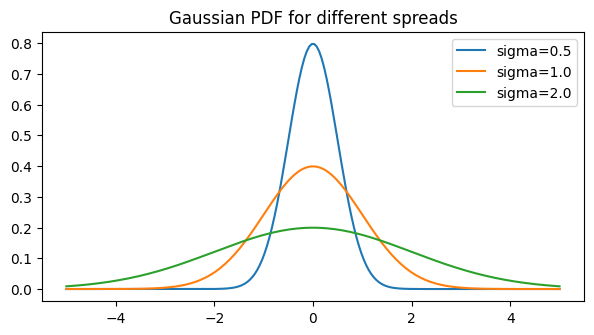

In [16]:
x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

Sample mean: 2.0064


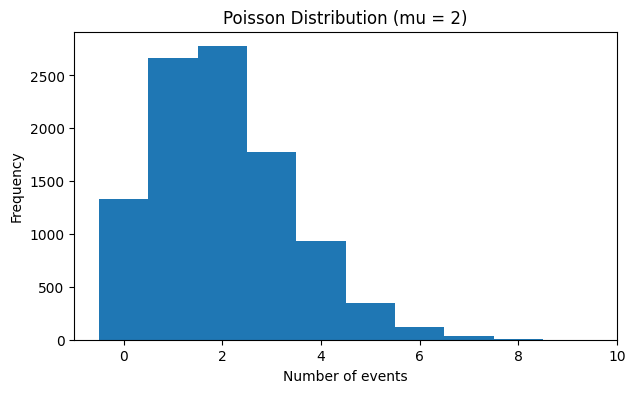

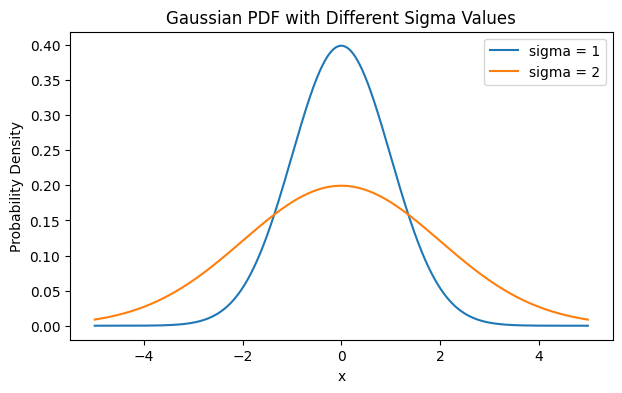

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
np.random.seed(42)
samples = np.random.poisson(lam=2, size=10000)
print("Sample mean:", samples.mean())
plt.figure(figsize=(7, 4))
plt.hist(samples, bins=np.arange(-0.5, samples.max() + 1.5, 1))
plt.xlabel("Number of events")
plt.ylabel("Frequency")
plt.title("Poisson Distribution (mu = 2)")
plt.show()
x = np.linspace(-5, 5, 1000)
mu = 0
sigma1 = 1
sigma2 = 2
pdf1 = norm.pdf(x, mu, sigma1)
pdf2 = norm.pdf(x, mu, sigma2)
plt.figure(figsize=(7, 4))
plt.plot(x, pdf1, label="sigma = 1")
plt.plot(x, pdf2, label="sigma = 2")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.title("Gaussian PDF with Different Sigma Values")
plt.legend()
plt.show()

In [18]:
from scipy.stats import entropy
fair   = [0.5, 0.5]      # a fair coin: maximum uncertainty
biased = [0.9, 0.1]      # a biased coin: more predictable
certain= [1.0, 0.0]      # no uncertainty at all
# base=2 gives entropy in BITS
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')

Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [19]:
P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3))
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3))

D(P || Q) = 0.737 bits
D(P || P) = 0.0
Note: D(P||Q) != D(Q||P)  -> 0.531


In [20]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris
iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


In [22]:
import numpy as np
from scipy.stats import entropy
p4 = np.ones(4) / 4
p6 = np.ones(6) / 6
H4 = entropy(p4, base=2)
H6 = entropy(p6, base=2)
print("Entropy of fair 4-sided die:", H4, "bits")
print("Entropy of fair 6-sided die:", H6, "bits")
if H6 > H4:
    print("The 6-sided die is more uncertain.")
P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])
KL = entropy(P, Q, base=2)
print("\nKL Divergence D(P || Q):", KL, "bits")
mi_scores = {
    "sepal length": 0.47,
    "sepal width": 0.23,
    "petal length": 0.99,
    "petal width": 0.99
}
most_informative = max(mi_scores, key=mi_scores.get)
least_informative = min(mi_scores, key=mi_scores.get)
print("\nMost informative feature:", most_informative)
print("Least informative feature:", least_informative)

Entropy of fair 4-sided die: 2.0 bits
Entropy of fair 6-sided die: 2.584962500721156 bits
The 6-sided die is more uncertain.

KL Divergence D(P || Q): 0.11870910076930725 bits

Most informative feature: petal length
Least informative feature: sepal width
